# 2. Cruzamento dos Dados (Enunciados + Microdados)

Este notebook realiza o cruzamento entre os enunciados extraídos das questões do ENEM e os microdados do ano correspondente, permitindo a análise detalhada das questões, incluindo parâmetros de dificuldade, gabaritos e amostragem do acerto de aluns. O processo de cruzamento segue o fluxo:

* **Input**: Local do CSV de Questões Extraídas + Local do CSV de Microdados

* **Output**: CSV com as colunas -> *numero_questao*, *enunciado*, *alternativas*, *nu_param_B* e *gabarito*

In [9]:
# Dependências para Cruzamento dos Dados
import pandas as pd
import matplotlib.pyplot as plt
import random

---
## 2.1. Amostragem do Acerto dos Alunos

In [ ]:
chunksize = 200_000  
reservoir = []
k = 100
n = 0
ano = 2009

# Código de cada ano da prova REGULAR e LEDOR do ENEM
codigos_prova = {
    "2009": 49,
    "2010": 89,
    "2011": 121,
    "2012": 141,
    "2013": 171,
    "2014": 199,
    "2015": 275,
    "2016": 291,
    "2017": 407,
    "2018": 463,
    "2019": 519,
    "2020": 604,
    "2021": 916,
    "2022": 1092,
    "2023": 1228,
}

In [ ]:
# Coleta "parcelada" de dados, a fim de não estourar a memória devido ao tamanho do csv
for chunk in pd.read_csv(
    f"MICRODADOS_ENEM_{ano}.csv",
    usecols=["CO_PROVA_CN", "TX_RESPOSTAS_CN"],
    chunksize=chunksize,
    encoding="ISO-8859-1",
    sep=";",
):

    # Queremos amostras relativas a Ciências da Natureza em que as pessoas tenham respondido ao menos uma questão
    sub = chunk[
        (chunk.CO_PROVA_CN == codigos_prova[str(ano)]) & (chunk.TX_RESPOSTAS_CN.notna())
    ]

    # Primeiras 100 linhas são incluídas na amostra
    # Para garantir iguais chances, após as 100 primeiras, sorteamos um número entre 100 e o número da variável
    # O número sorteado é a posição dela - queremos apenas as 100 primeiras
    for _, row in sub.iterrows():
        n += 1
        if len(reservoir) < k:
            reservoir.append(row)
        else:
            s = random.randrange(n)
            if s < k:
                reservoir[s] = row

# Criação do DataFrame da amostra
df_amostra = pd.DataFrame(reservoir)

In [ ]:
# Para cada pessoa, há um vetor de 45 caracteres. Cada caractere é a resposta da questão de CN ordenada
resp_expanded = df_amostra["TX_RESPOSTAS_CN"].apply(lambda s: pd.Series(list(s)))

# Converter a string de 45 caracteres para 45 colunas
resp_expanded.columns = [f"questao_{i+1}" for i in range(resp_expanded.shape[1])]
df_final = pd.concat(
    [df_amostra.drop(columns=["TX_RESPOSTAS_CN"]), resp_expanded], axis=1
)

# Salvar amostra em um novo CSV
df_final.to_csv(
    f"amostra_microdados_respostas_{ano}.csv",
    sep=";",
    index=False,
    encoding="ISO-8859-1",
)

---
## 2.2. Cruzando Microdados

In [ ]:
codigos_prova = {
    "2009": 49,
    "2010": 89,
    "2011": 121,
    "2012": 141,
    "2013": 171,
    "2014": 199,
    "2015": 275,
    "2016": 291,
    "2017_LEDOR": 407,
    "2018_LEDOR": 463,
    "2019_LEDOR": 519,
    "2020_LEDOR": 604,
    "2021_LEDOR": 916,
    "2022_LEDOR": 1092,
    "2023_LEDOR": 1228,
}

In [14]:
# Definição de Variáveis de Input e Output
start_year = 2009
end_year = 2023

output_path = "../data/final/enem_data.csv"

In [15]:
# Lista para armazenar os DataFrames de cada ano
merged_dfs = []

# Iterando sobre cada ano extraído
for year in range(start_year, end_year + 1):

    # Extrair da Prova LEDOR a partir de 2017 (mais descritiva)
    flag_ledor: bool = year >= 2017
    questions_year = str(year)
    if flag_ledor:
        questions_year += "_LEDOR"

    # Ler o CSV extraído do PDF referente (resultado de 1. Extração dos Enunciados.ipynb + Revisão Manual)
    df_questions = pd.read_csv(f"../data/processed_reviewed/enem_{questions_year}.csv", encoding="utf-8", quotechar='"')

    # Ler os CSVs de microdados do ano referente
    df_microdados = pd.read_csv(f"../data/raw/microdados/microdados_{year}.csv", delimiter=";", encoding="latin1")
    df_respostas = pd.read_csv(f"../data/raw/microdados/amostra_microdados_respostas_{year}.csv", delimiter=";", encoding="latin1")

    # Preparação de df_respostas para merge com prova
    quest_cols = [int(col.split("_")[1]) for col in df_respostas.columns if col.startswith('questao_')]

    df_respostas = pd.DataFrame({
        'questao': quest_cols,
        'respostas': pd.Series([df_respostas["questao_" + str(col)].tolist() for col in quest_cols])
    })

    if year == 2009:
        df_respostas["questao"] = df_respostas["questao"] 
    elif year <= 2016:
        df_respostas["questao"] += 45
    elif year <= 2023:
        df_respostas["questao"] += 90

    # Filtrando os microdados para SG_AREA, TX_COR e CO_PROVA
    # ATENÇÃO: O Código da Prova para a Aplicação Regular muda a cada ano
    cor_prova = "LARANJA" if flag_ledor else "AZUL"
    df_microdados_filtrado = df_microdados[
        (df_microdados["SG_AREA"] == "CN")  # Ciência das Naturezas
        & (
            (df_microdados["TX_COR"].str.upper() == cor_prova) 
        )  # Apenas caderno azul e laranja em caso de LEDOR
        & (df_microdados["CO_PROVA"] == codigos_prova[questions_year])  # Aplicação Regular ou LEDOR
    ]


    # Selecionar apenas as colunas de interesse dos microdados
    df_microdados_selected = df_microdados_filtrado[
        ["CO_POSICAO", "NU_PARAM_B", "TX_GABARITO"]
    ].copy()

    # Fix no ano de 2016 e 2017 (erro microdados)
    if year == 2017:
        df_microdados_selected["CO_POSICAO"] += 90
    if year == 2016:
        df_microdados_selected["CO_POSICAO"] -= 45

    # Certificar que os tipos das chaves de junção são compatíveis
    df_respostas["questao"] = df_respostas["questao"].astype(str)
    df_questions["numero_questao"] = df_questions["numero_questao"].astype(str)
    df_microdados_selected["CO_POSICAO"] = df_microdados_selected["CO_POSICAO"].astype(str)

    # Fazer o cruzamento usando o número da questão (numero_questao e CO_POSICAO)
    df_merged = pd.merge(
        df_questions,
        df_microdados_selected,
        left_on="numero_questao",
        right_on="CO_POSICAO",
        how="left",
    )
    
    # Fazer o cruzamento usando o número da questão (numero_questao e questao)
    df_merged = pd.merge(
        df_merged,
        df_respostas,
        left_on="numero_questao",
        right_on="questao",
        how="left",
    )

    # Calculando percentual de acertos da amostra
    df_merged['pc_amostra_acertos'] = df_merged.apply(
        lambda row: row['respostas'].count(row['TX_GABARITO']) / len(row['respostas']),
        axis=1
    )

    # Remover a coluna CO_POSICAO (redundante)
    df_merged.drop(columns=["CO_POSICAO", "respostas", "questao"], inplace=True)

    # Renomeando colunas
    df_merged.rename(columns={
        "NU_PARAM_B": "nu_param_B",
        "TX_GABARITO": "gabarito"
    }, inplace=True)

    # Adicionando coluna do ano
    df_merged["ano"] = year

    merged_dfs.append(df_merged)

# Concatenar todos os DataFrames em um único
df_final = pd.concat(merged_dfs, ignore_index=True)

# Salvando DF resultante
df_final.to_csv(output_path, index=False, encoding="utf-8")

In [5]:
# Verificando o resultado
df = pd.read_csv(output_path)
df.head()

,numero_questao,enunciado,alternativas,nu_param_B,gabarito,pc_amostra_acertos,ano
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,-1.70677,C,0.93,2009
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,0.62043,D,0.40,2009
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",2.07704,A,0.40,2009
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,0.11500,B,0.61,2009
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,0.21694,E,0.60,2009


---
## 2.3. Removendo Questões Sem Dificuldade

In [16]:
dificuldades_null = df["nu_param_B"].isna().sum()
print(f"Questões sem parâmetro B (dificuldade): {dificuldades_null}")

Questões sem parâmetro B (dificuldade): 16


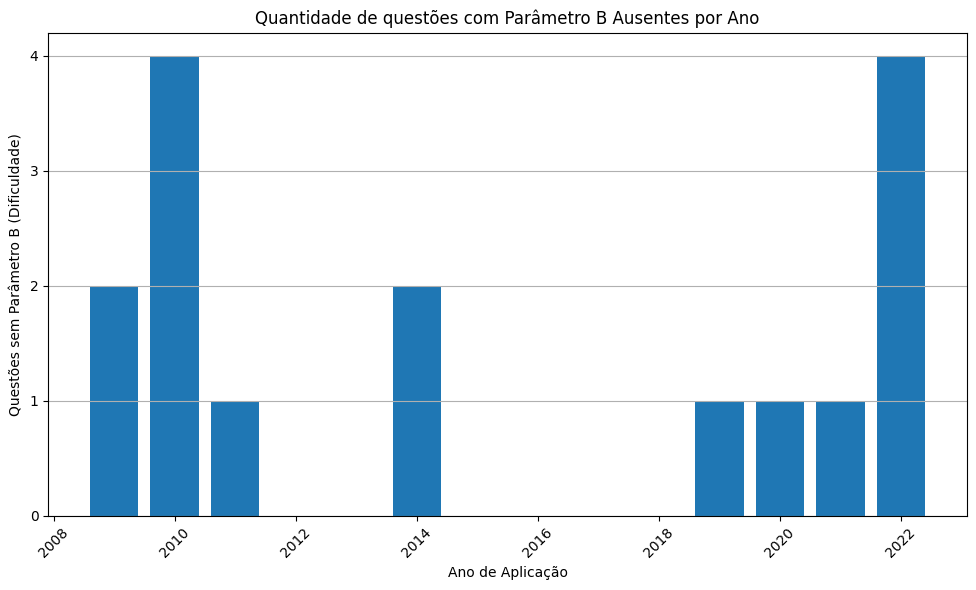

In [ ]:
from matplotlib.ticker import MaxNLocator

# Filtrar valores ausentes e agrupar por ano
missing_df = df[df["nu_param_B"].isna()].groupby("ano").size().reset_index(name="missing_nu_param_B")

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.bar(missing_df["ano"], missing_df["missing_nu_param_B"])
plt.title("Quantidade de Questões sem Parâmetro B (Dificuldade) por Ano")
plt.xlabel("Ano de Aplicação")
plt.ylabel("Questões sem Parâmetro B (Dificuldade)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [8]:
# Remover linhas sem valor em nu_param_B
df_final = df_final.dropna(subset=["nu_param_B"])

# Salvando DF resultante
df_final.to_csv(output_path, index=False, encoding="utf-8")

print("Questões sem parâmetro de dificuldade removidas")

Questões sem parâmetro de dificuldade removidas


---